In [1]:
import dask
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmcrameri as cm
import os
import matplotlib.gridspec as gridspec  
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
dask.config.set(**{'array.slicing.split_large_chunks': True})

In [2]:
import babet as bb
import atmicp

In [3]:
def diff_with_offset(a, b, dim="inidate", offset=1):
    return a.isel({dim: slice(0, -offset)}) - b.isel({dim: slice(offset, None)})

# Import data

In [4]:
ifs_pl = atmicp.Data.get_ifs_data(levtype='pl', res='GLO100', cf_option=['cf'])

/home/e/ermis/nobackups/miniforge3/envs/babet-3-7-12_new/lib/python3.7/site-packages/dask/array/core.py:4608: PerformanceWarning: Increasing number of chunks by factor of 13
  **blockwise_kwargs,
/home/e/ermis/nobackups/miniforge3/envs/babet-3-7-12_new/lib/python3.7/site-packages/dask/array/core.py:4608: PerformanceWarning: Increasing number of chunks by factor of 13
  **blockwise_kwargs,
/home/e/ermis/nobackups/miniforge3/envs/babet-3-7-12_new/lib/python3.7/site-packages/dask/array/core.py:4608: PerformanceWarning: Increasing number of chunks by factor of 13
  **blockwise_kwargs,
/home/e/ermis/nobackups/miniforge3/envs/babet-3-7-12_new/lib/python3.7/site-packages/dask/array/core.py:4608: PerformanceWarning: Increasing number of chunks by factor of 13
  **blockwise_kwargs,
/home/e/ermis/nobackups/miniforge3/envs/babet-3-7-12_new/lib/python3.7/site-packages/dask/array/core.py:4608: PerformanceWarning: Increasing number of chunks by factor of 13
  **blockwise_kwargs,
/home/e/ermis/noback

# control member delta

In [9]:
ifs_pl.sel(climate='curr', inidate='2021-06-15')

,Array,Chunk
Bytes,375.83 MiB,9.94 MiB
Shape,"(3, 63, 1, 8, 181, 360)","(1, 5, 1, 8, 181, 360)"
Count,7742 Tasks,39 Chunks
Type,float32,numpy.ndarray
,Array,Chunk
Bytes,375.83 MiB,9.94 MiB
Shape,"(3, 63, 1, 8, 181, 360)","(1, 5, 1, 8, 181, 360)"
Count,7742 Tasks,39 Chunks
Type,float32,numpy.ndarray
,Array,Chunk


In [11]:
# global at 00UTC difference to the previous initidalisation

delta_maps = {}
for climate in ['pi', 'incr']:
    delta_maps[climate] = {}
    for pert in ['t+q', 'progn_vars']:
        tmp1 = ifs_pl.sel(perturbation=pert, climate=climate)
        tmp2 = ifs_pl.sel(perturbation='none', climate='curr')
        ifs_diff = diff_with_offset(tmp1, tmp2, dim='inidate', offset=1)

        ifs_diff_delta = []

        for i, ini in enumerate(ifs_diff.inidate.values):
            inidate_data = ifs_diff.sel(inidate=ini)
            timesteps = [ini+np.timedelta64(0,'h')] #[ini+np.timedelta64(0, 'h'), ini+np.timedelta64(24, 'h')]
            ifs_diff_delta.append(inidate_data.sel(time=timesteps).squeeze('time', drop=True))

        ifs_diff_delta = xr.concat(ifs_diff_delta, dim='inidate')
        delta_maps[climate][pert] = ifs_diff_delta.mean(dim=['number']).compute()

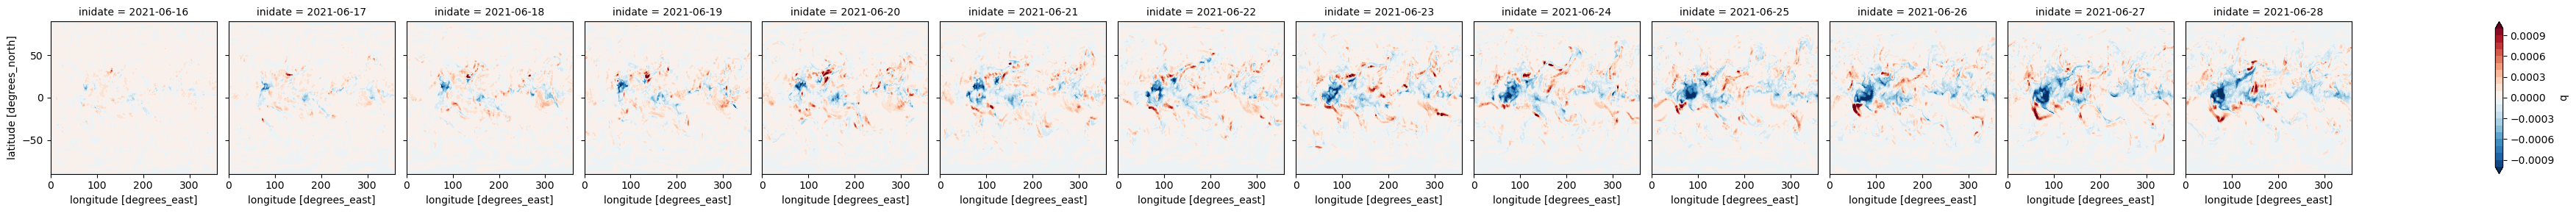

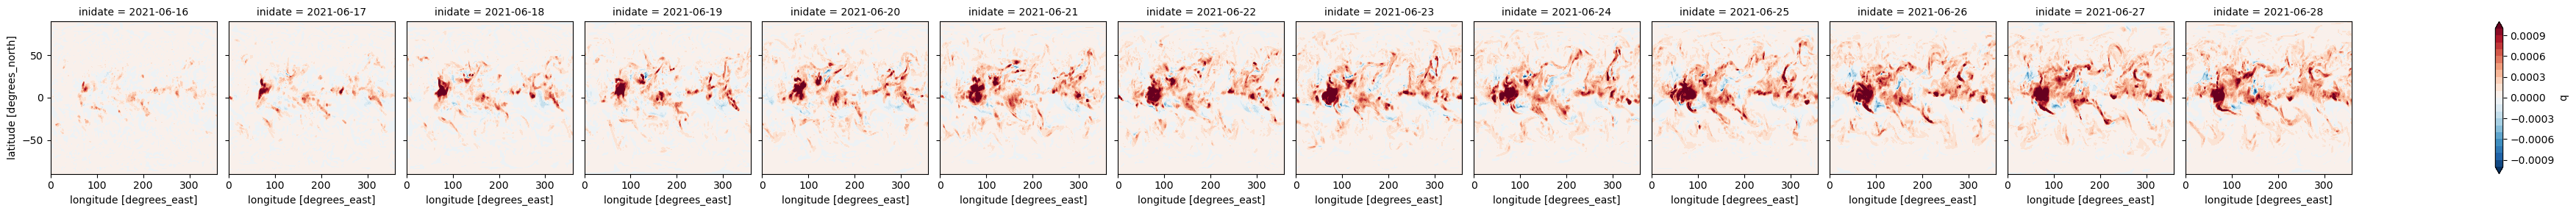

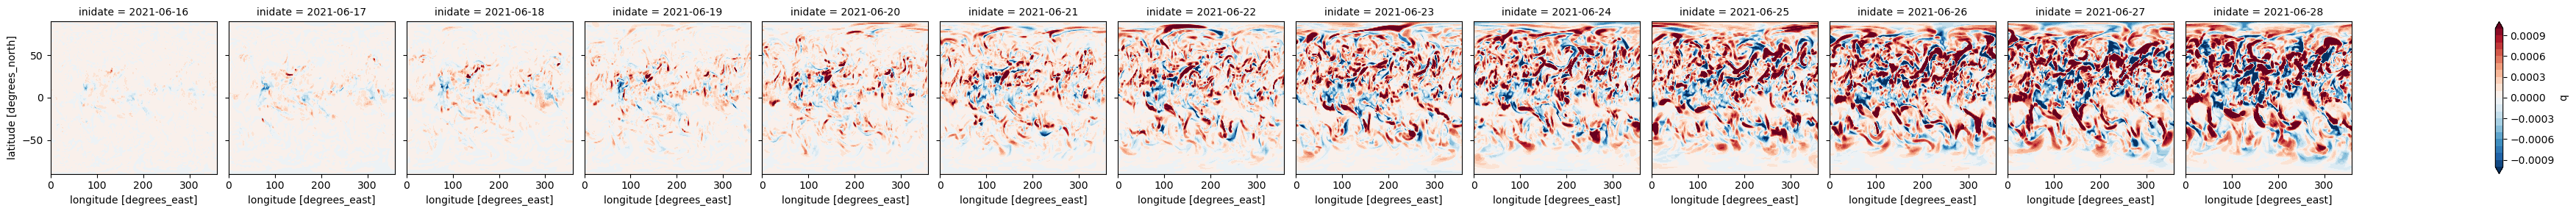

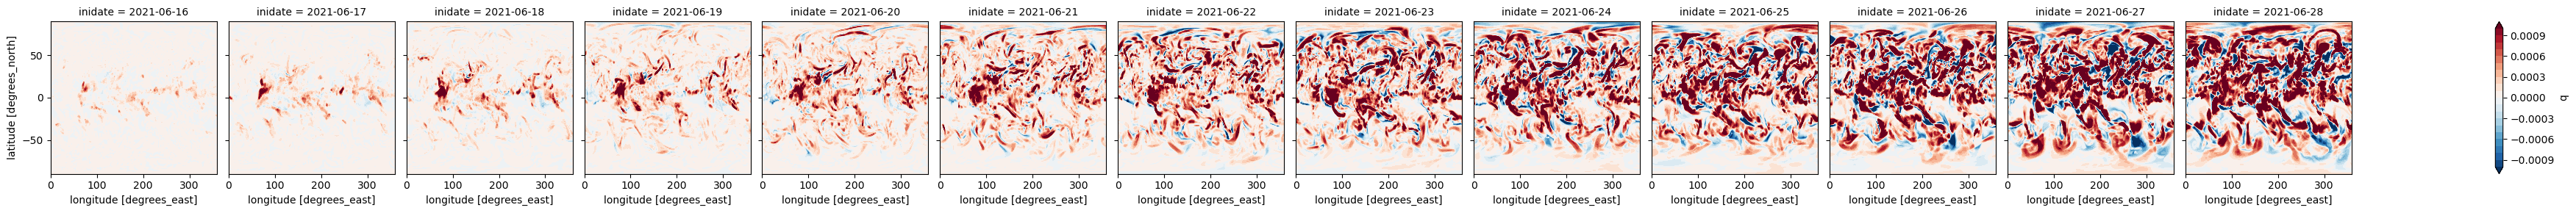

In [16]:
v = 0.001
delta_maps['pi']['t+q'].sel(level=500).q.plot.contourf(col='inidate', vmin=-1*v, vmax=v, cmap='RdBu_r', levels=21, title='pi, t+q')
delta_maps['incr']['t+q'].sel(level=500).q.plot.contourf(col='inidate', vmin=-1*v, vmax=v, cmap='RdBu_r', levels=21, title='incr, t+q')

delta_maps['pi']['progn_vars'].sel(level=500).q.plot.contourf(col='inidate', vmin=-1*v, vmax=v, cmap='RdBu_r', levels=21, title='pi, progn_vars')
delta_maps['incr']['progn_vars'].sel(level=500).q.plot.contourf(col='inidate', vmin=-1*v, vmax=v, cmap='RdBu_r', levels=21, title='incr, progn_vars')

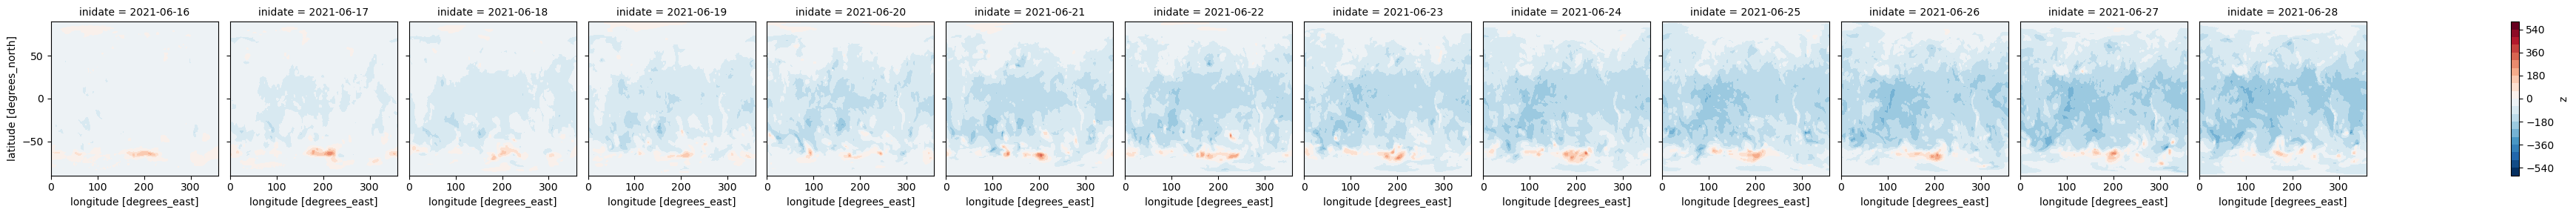

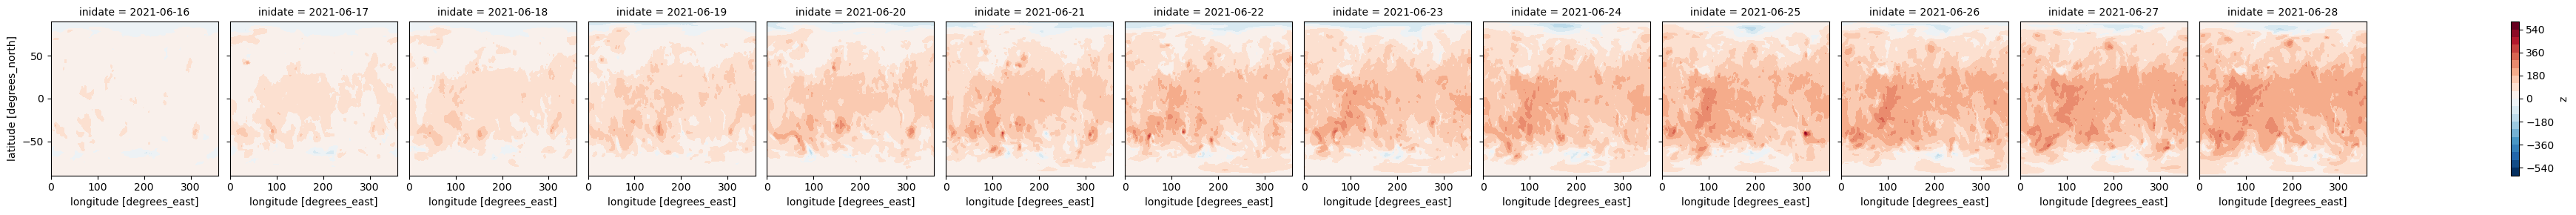

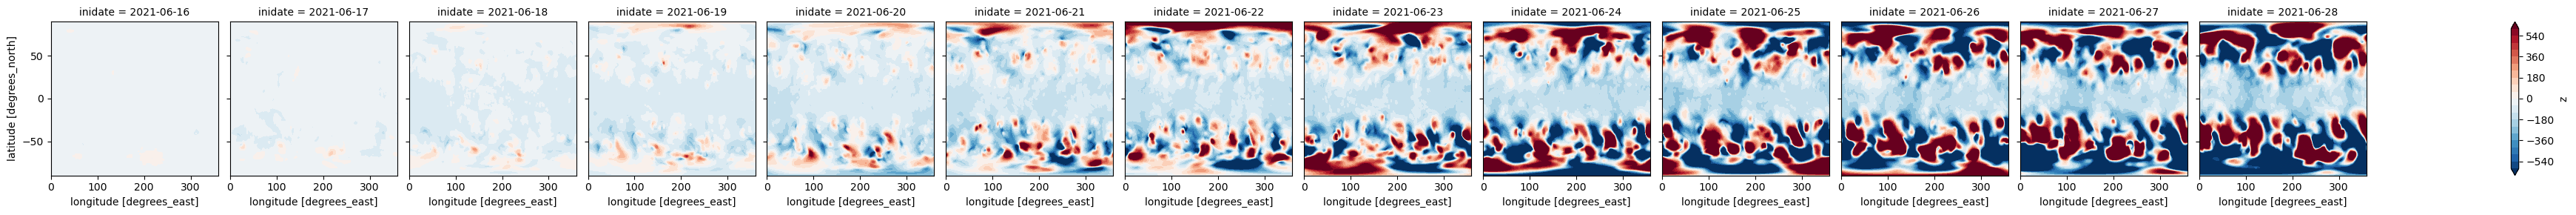

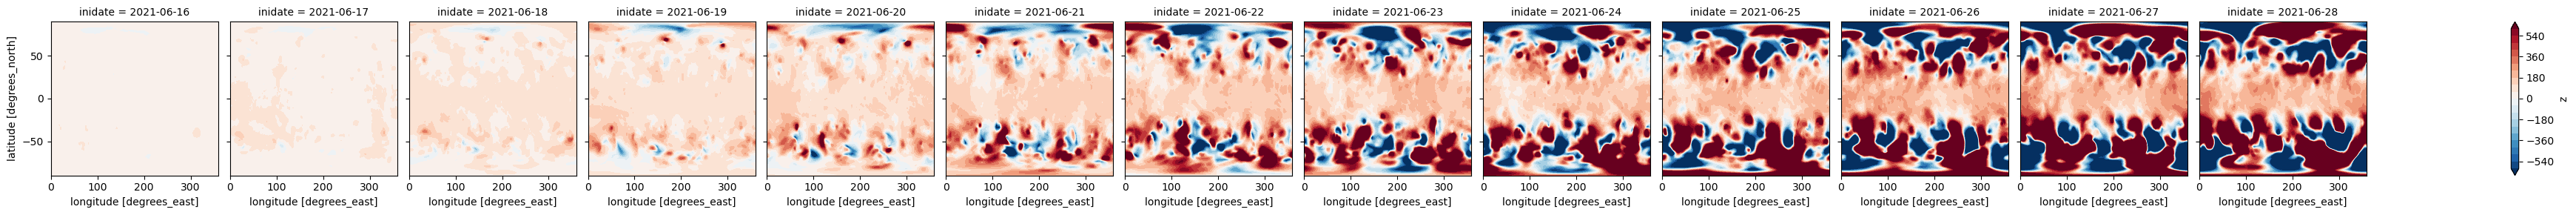

In [20]:
v = 600
delta_maps['pi']['t+q'].sel(level=500).z.plot.contourf(col='inidate', vmin=-1*v, vmax=v, cmap='RdBu_r', levels=21, title='pi, t+q')
delta_maps['incr']['t+q'].sel(level=500).z.plot.contourf(col='inidate', vmin=-1*v, vmax=v, cmap='RdBu_r', levels=21, title='incr, t+q')

delta_maps['pi']['progn_vars'].sel(level=500).z.plot.contourf(col='inidate', vmin=-1*v, vmax=v, cmap='RdBu_r', levels=21, title='pi, progn_vars')
delta_maps['incr']['progn_vars'].sel(level=500).z.plot.contourf(col='inidate', vmin=-1*v, vmax=v, cmap='RdBu_r', levels=21, title='incr, progn_vars')

# Geopotential height fields

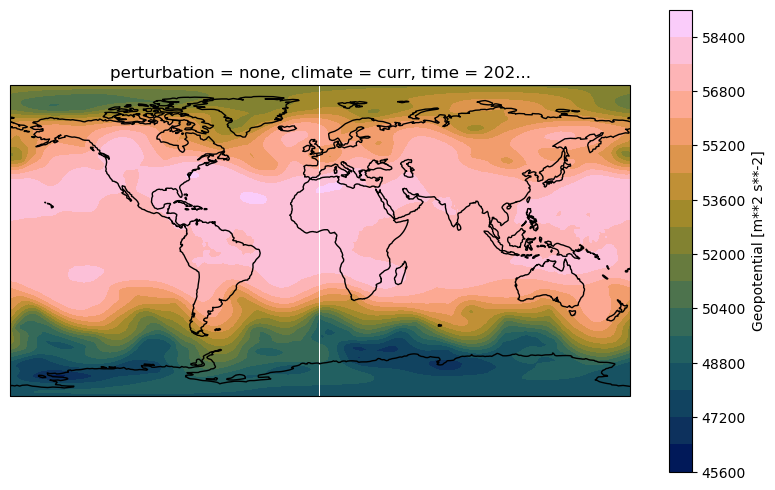

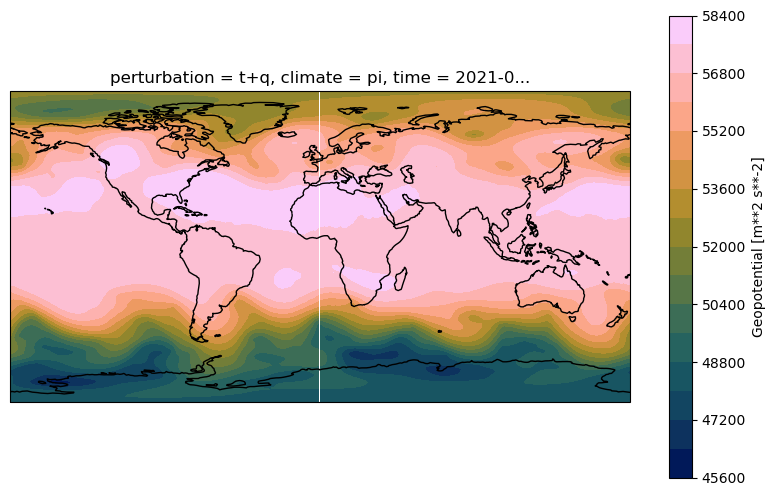

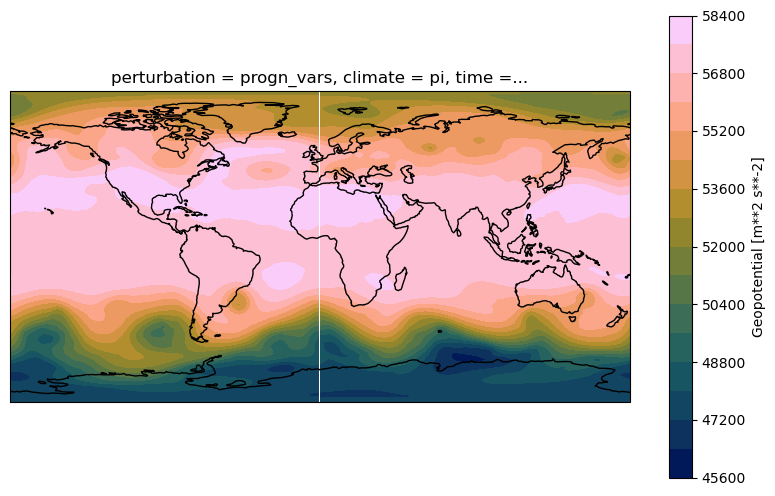

In [13]:
figure = plt.figure(figsize=(10, 6))
ax = figure.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines()
ifs_pl.sel(climate='curr', inidate='2021-06-28', level=500, perturbation='none', number=0, time='2021-06-30T00:00:00').z.plot.contourf(ax=ax, levels=21, cmap=cm.cm.batlow, transform=ccrs.PlateCarree())

figure = plt.figure(figsize=(10, 6))
ax = figure.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines()
ifs_pl.sel(climate='pi', inidate='2021-06-28', level=500, perturbation='t+q', number=0, time='2021-06-30T00:00:00').z.plot.contourf(ax=ax, levels=21, cmap=cm.cm.batlow, transform=ccrs.PlateCarree())

figure = plt.figure(figsize=(10, 6))
ax = figure.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines()
ifs_pl.sel(climate='pi', inidate='2021-06-28', level=500, perturbation='progn_vars', number=0, time='2021-06-30T00:00:00').z.plot.contourf(ax=ax, levels=21, cmap=cm.cm.batlow, transform=ccrs.PlateCarree())

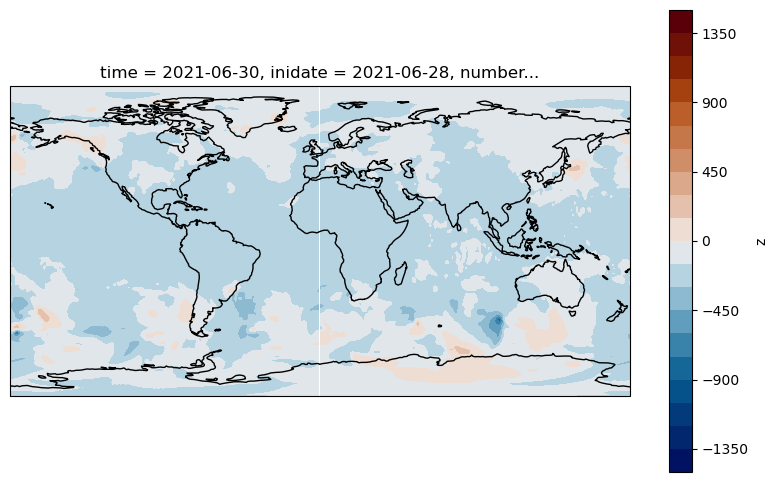

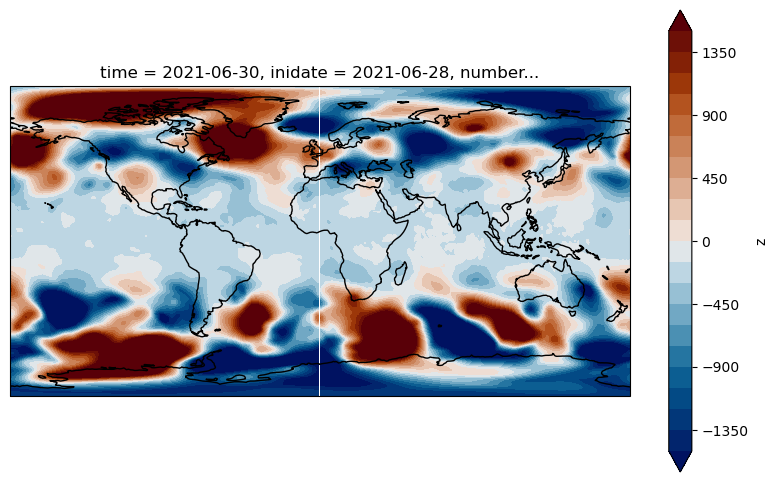

In [17]:
vmin=1500
figure = plt.figure(figsize=(10, 6))
ax = figure.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines()
(ifs_pl.sel(climate='pi', perturbation='t+q')-ifs_pl.sel(climate='curr', perturbation='none')).sel(inidate='2021-06-28', level=500, number=0, time='2021-06-30T00:00:00').z.plot.contourf(ax=ax, levels=21, cmap=cm.cm.vik, transform=ccrs.PlateCarree(), vmin=-1*vmin, vmax=vmin)

figure = plt.figure(figsize=(10, 6))
ax = figure.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines()
(ifs_pl.sel(climate='pi', perturbation='progn_vars')-ifs_pl.sel(climate='curr', perturbation='none')).sel(inidate='2021-06-28', level=500, number=0, time='2021-06-30T00:00:00').z.plot.contourf(ax=ax, levels=21, cmap=cm.cm.vik, transform=ccrs.PlateCarree(), vmin=-1*vmin, vmax=vmin)